Epoch 1/55
278/278 [==============================] - 5s 9ms/step - loss: 0.0785 - val_loss: 0.0655
Epoch 2/55
278/278 [==============================] - 3s 9ms/step - loss: 0.0611 - val_loss: 0.0554
Epoch 3/55
278/278 [==============================] - 3s 11ms/step - loss: 0.0475 - val_loss: 0.0403
Epoch 4/55
278/278 [==============================] - 3s 9ms/step - loss: 0.0355 - val_loss: 0.0305
Epoch 5/55
278/278 [==============================] - 3s 9ms/step - loss: 0.0277 - val_loss: 0.0245
Epoch 6/55
278/278 [==============================] - 3s 9ms/step - loss: 0.0225 - val_loss: 0.0197
Epoch 7/55
278/278 [==============================] - 3s 12ms/step - loss: 0.0184 - val_loss: 0.0162
Epoch 8/55
278/278 [==============================] - 3s 10ms/step - loss: 0.0147 - val_loss: 0.0125
Epoch 9/55
278/278 [==============================] - 3s 9ms/step - loss: 0.0117 - val_loss: 0.0105
Epoch 10/55
278/278 [==============================] - 3s 10ms/step - loss: 0.0101 - val_loss: 0.

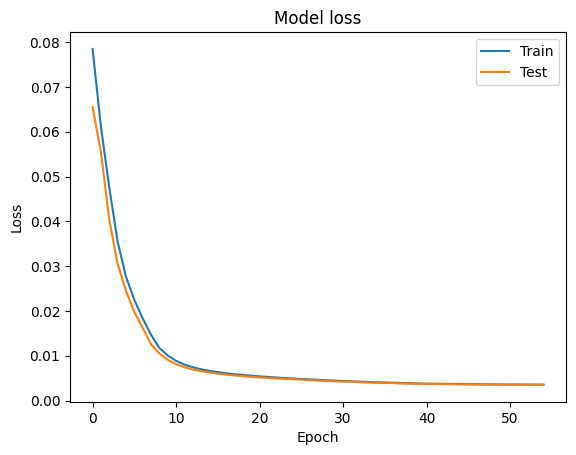

313/313 [==============================] - 5s 12ms/step
[0, 8, 1, 4, 2, 6, 8, 1, 5, 5]
mse and ssim for image 0 are 0.001960617817907025 and 0.9521501489500767
mse and ssim for image 1 are 0.004986401254175339 and 0.9238430772096865
mse and ssim for image 2 are 0.000874468661039451 and 0.8989501656116894
mse and ssim for image 3 are 0.0025188341529745386 and 0.8918237110413132
mse and ssim for image 4 are 0.0035929526035640862 and 0.8912472681170521
mse and ssim for image 5 are 0.0020722241597608783 and 0.9228193673824743
mse and ssim for image 6 are 0.003123388842789419 and 0.9383258750437158
mse and ssim for image 7 are 0.0007522659777654635 and 0.8998934979093258
mse and ssim for image 8 are 0.008320541782722058 and 0.8670493567932235
mse and ssim for image 9 are 0.0021166500687085613 and 0.889031978478478


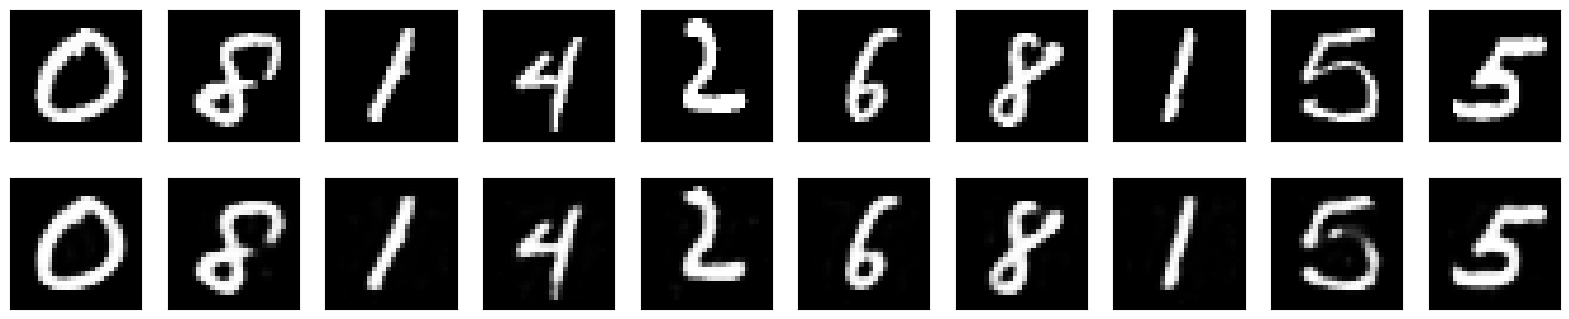

[0, 8, 1, 4, 2, 6, 8, 1, 5, 5]
[0, 8, 1, 4, 2, 6, 8, 1, 5, 5]


In [6]:
import numpy as np
import tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.layers import Layer 
from skimage import metrics
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

class RatioActivation(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(RatioActivation, self).__init__(**kwargs)
        self.a0 = tf.Variable(0.5, name='a0', dtype=tf.float32,trainable=True)
        self.a1 = tf.Variable(0.5, name='a1', dtype=tf.float32,trainable=True)
        self.a2 = tf.Variable(0.5, name='a2', dtype=tf.float32,trainable=True)
        self.a3 = tf.Variable(0.5, name='a3', dtype=tf.float32,trainable=True)
        self.b1 = tf.Variable(0.5, name='b1', dtype=tf.float32,trainable=True)
        self.b2 = tf.Variable(0.5, name='b2', dtype=tf.float32,trainable=True)
        self.b3 = tf.Variable(0.5, name='b3', dtype=tf.float32,trainable=True)

    def call(self, inputs):
        numerator = self.a0 + self.a1 * inputs + self.a2 * tf.pow(inputs, 2) + self.a3 * tf.pow(inputs, 3)
        denominator = 1 + self.b1 * inputs + self.b2 * tf.pow(inputs, 2) + self.b3 * tf.pow(inputs, 3)
        return numerator / denominator

    def get_config(self):
        config = super().get_config().copy()
        config.update({'a0': self.a0,'a1': self.a1, 'a2': self.a2, 'a3': self.a3, 
                       'b1': self.b1, 'b2': self.b2, 'b3': self.b3})
        return config
    
tf.keras.utils.get_custom_objects()['RatioActivation'] = RatioActivation

# Load the MNIST dataset
(x_train, train_labels), (x_test, test_labels) = mnist.load_data()

# Normalize the data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Flatten the images
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

# Randomize both the training and test
permutation = np.random.permutation(len(x_train))
x_train, train_labels = x_train[permutation], train_labels[permutation]
permutation = np.random.permutation(len(x_test))
x_test, test_labels = x_test[permutation], test_labels[permutation]


# Create the encoder
encoder_input = Input(shape=(784,))
x = Dense(64)(encoder_input)
encoded = RatioActivation()(x)  # Apply RatioActivation as a separate layer
encoder = Model(encoder_input, encoded)

# Create the decoder
decoder_input = Input(shape=(64,))
decoded = Dense(784, activation='sigmoid')(decoder_input)
decoder = Model(decoder_input, decoded)

# Create the autoencoder
autoencoder = Model(encoder_input, decoder(encoder(encoder_input)))

lr_schedule = tensorflow.keras.optimizers.schedules.ExponentialDecay(initial_learning_rate = 5e-01, decay_steps = 2500, decay_rate = 0.75,staircase=True) 
tensorflow.keras.optimizers.Adam(learning_rate = lr_schedule,beta_1=0.95,beta_2=0.99,epsilon=1e-01)
autoencoder.compile(optimizer='adam', loss='mean_squared_error')

# Train the autoencoder
history = autoencoder.fit(x_train, x_train,
                epochs=55,
                batch_size=216,
                shuffle=True,
                validation_data=(x_test, x_test))


# Access the trained parameters
# Get the correct layer name
ratio_activation_layers = [layer for layer in encoder.layers if isinstance(layer, RatioActivation)]
if ratio_activation_layers:
    ratio_activation_layer = ratio_activation_layers[0]
    a0, a1, a2, a3 = ratio_activation_layer.a0.numpy(), ratio_activation_layer.a1.numpy(), ratio_activation_layer.a2.numpy(), ratio_activation_layer.a3.numpy()
    b1, b2, b3 = ratio_activation_layer.b1.numpy(), ratio_activation_layer.b2.numpy(), ratio_activation_layer.b3.numpy()
    print(f'a0: {a0}, a1: {a1}, a2: {a2}, a3: {a3}, b1: {b1}, b2: {b2}, b3: {b3}')

                                         
# Plot the training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

# Plot the test figures vs. predicted figures
decoded_imgs = autoencoder.predict(x_test)

def mse(imageA, imageB):
    err = np.sum((imageA.astype("float") - imageB.astype("float")) ** 2)
    err /= float(imageA.shape[0])
    return err

def ssim(imageA, imageB):
    return metrics.structural_similarity(imageA, imageB, channel_axis=None, data_range=1.0)

decomser = [] 
decossimr = [] 
n = 10
list_xtestn = [ [x_test[i], test_labels[i]] for i in range(10)] 
print([list_xtestn[i][1] for i in range(n)]) 
                                         
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
                                         
    if mse(list_xtestn[i][0],decoded_imgs[i]) <= 0.01: 
        msel = mse(list_xtestn[i][0],decoded_imgs[i])
        decomser.append(list_xtestn[i][1])  
    if ssim(list_xtestn[i][0],decoded_imgs[i]) > 0.85:
        ssiml = ssim(list_xtestn[i][0],decoded_imgs[i])
        decossimr.append(list_xtestn[i][1])   
    print("mse and ssim for image %s are %s and %s" %(i,msel,ssiml))                                     
plt.show()


print(decomser)
print(decossimr)